# Traffic Accident Analysis 

This notebook is for analyzing traffic accident data provided by the Finnish Transport Infrastructure Agency in order to find factors associated with accident severity and to discover typical accident patterns. 

### Research Question 1: Can accident severity be predicted based on the available features?
### Research Question 2: How much do weather conditions affect accident severity?
### Research Question 3: Are there identifiable accident profiles (clusters)?

The first two are classification problems, while the third is an unsupervised learning problem. Suitable models for classification include Decision Trees, Random Forests and Logistic Regression while for clustering the K-Means algorithm can be used.

# Data Understanding
The data is in CSV format per year and contains information about traffic accidents in Finland. The data can be fetched from this URL: https://aineistot.vayla.fi/spa/ava/Tie/Tieliikenneonnettomuudet/

In readme.txt file, it is mentioned that not all years have the same columns and also that the data model changed in 2022 dividing the data into pre and post 2022 datasets. As this project was done as a part of a course and the focus on the analysis would be on modeling, only a moderate effort was put into the issue of combining the datasets. During closer inspection, it was also discovered that the different datasets had different encodings which would have to be taken into consideration when reading and parseing the data.

In the code cell below is a simple approach of inspectin the combination of the datasets. If all data from the years 2015-2024 were combined, the resulting dataset would have 0 common columns. The dataset for the year 2024 is not finalized and had a completely different structure and thus made it impossible to combine with the other datasets. After dropping the 2024 dataset, the combined dataset for years 2015-2023 had 12 common columns and after some slight normalization of column names, the amount of common columns increased to 16. With data from the years 2015-2021, the amount of common columns was 95. 


In [53]:
# ENNEN PALAUTUSTA TÄHÄN prepare_data.ipynb:in EKA SOLU!
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier


As the focus of the analysis is on modeling, the dataset for years 2015-2021 was chosen for further analysis as it had the most common columns with equal data types making it the most suitable for modeling without spending too much time on data cleaning and preprocessing. Another solution would be to pick the data after 2022, but this would have resulted in a much smaller dataset with only 3 years of data and thus was not chosen. In the following code cell the dataset for years 2015-2021 is read into a dataframe for further preprocessing. The datapackage.json is used to get the dtypes of the columns to make sure that the data is read with the correct dtypes.

In [54]:
# ENNEN PALAUTUSTA TÄHÄN prepare_data.ipynb:in TOKA SOLU!

In [55]:
combined_df = pd.read_parquet("combined_2015_2021.parquet")
combined_df.head()

,Onnett_id,Tienpit,Tienpitsel,Tie,Aosa,Aet,Ajr,Vuosi,Kk,Vakavuusko,...,Poikkileik,Poikleikse,Päällyslev,Päällystlk,Päällksel,Nakos150,Nakos300,Nakos460,Runkotie,Raskos
0,6891249,1,Liikennevirasto,1,2,2554,1,2015,9,0,...,2,2 ajor,<NA>,-1,Ei arvoa,<NA>,<NA>,<NA>,0,ei
1,6584643,1,Liikennevirasto,1,3,3,2,2015,10,0,...,2,2 ajor,114,10,kovat asfaltit,97,76,57,1,ei
2,6681113,1,Liikennevirasto,1,3,6,2,2015,1,0,...,2,2 ajor,114,10,kovat asfaltit,97,76,57,1,ei
3,6840692,1,Liikennevirasto,1,3,8,1,2015,7,0,...,2,2 ajor,104,10,kovat asfaltit,97,76,57,1,ei
4,6740912,1,Liikennevirasto,1,3,9,2,2015,10,0,...,2,2 ajor,114,10,kovat asfaltit,97,76,57,1,ei


In [56]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116106 entries, 0 to 116105
Data columns (total 95 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Onnett_id    116106 non-null  Int64 
 1   Tienpit      116106 non-null  Int64 
 2   Tienpitsel   116106 non-null  object
 3   Tie          75773 non-null   Int64 
 4   Aosa         75498 non-null   Int64 
 5   Aet          62619 non-null   Int64 
 6   Ajr          62603 non-null   Int64 
 7   Vuosi        116106 non-null  Int64 
 8   Kk           116106 non-null  Int64 
 9   Vakavuusko   116106 non-null  Int64 
 10  Vakavuus     116106 non-null  object
 11  ELY          116106 non-null  Int64 
 12  Elynimi      116106 non-null  object
 13  Vkpv         116106 non-null  object
 14  Ontyyppi     116106 non-null  Int64 
 15  Ontyypsel    116106 non-null  object
 16  Onluokka     116106 non-null  Int64 
 17  Onlksel      116106 non-null  object
 18  Osallkm      116106 non-null  Int64 
 19  Nopraj       

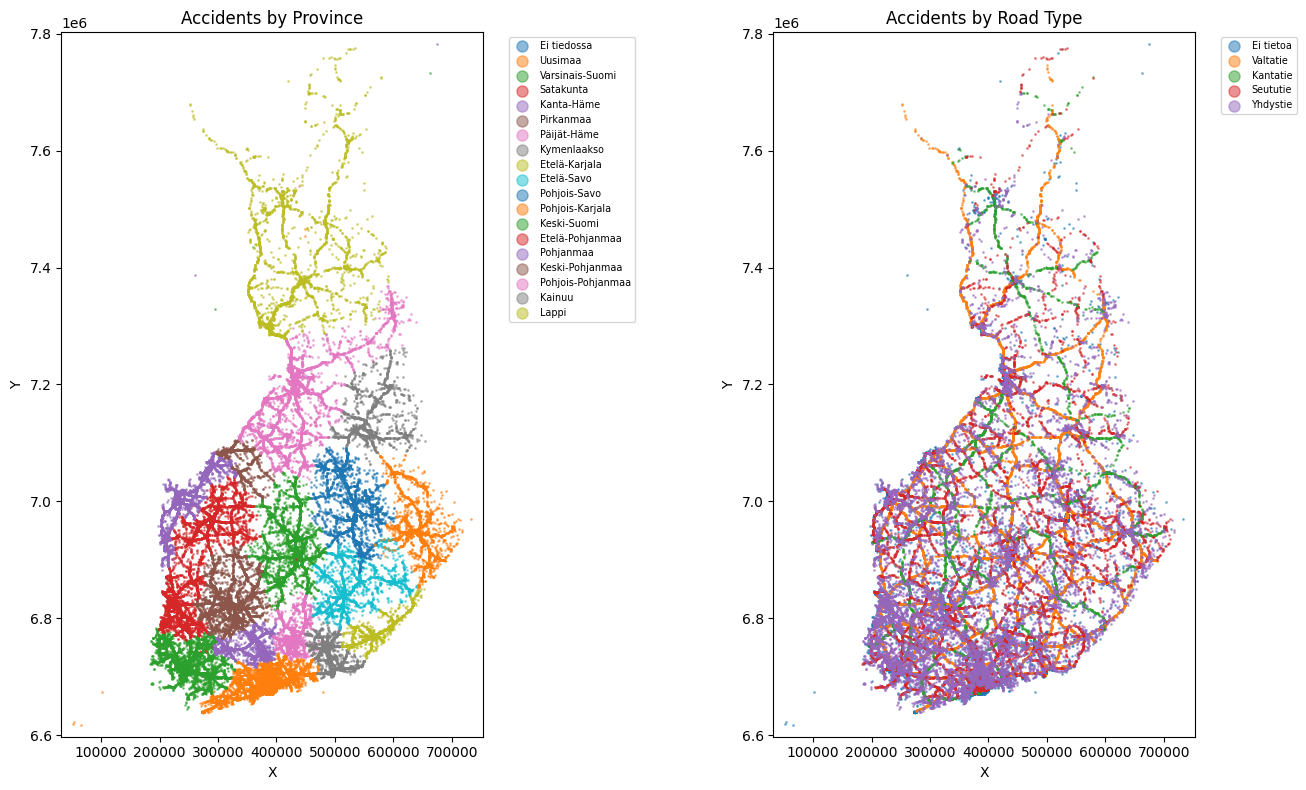

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

province_map = {
    0: "Ei tiedossa", 1: "Uusimaa", 2: "Varsinais-Suomi", 4: "Satakunta",
    5: "Kanta-Häme", 6: "Pirkanmaa", 7: "Päijät-Häme", 8: "Kymenlaakso",
    9: "Etelä-Karjala", 10: "Etelä-Savo", 11: "Pohjois-Savo",
    12: "Pohjois-Karjala", 13: "Keski-Suomi", 14: "Etelä-Pohjanmaa",
    15: "Pohjanmaa", 16: "Keski-Pohjanmaa", 17: "Pohjois-Pohjanmaa",
    18: "Kainuu", 19: "Lappi", 21: "Ahvenanmaa"
}

road_type_map = {
    -1: "Ei tietoa", 1: "Valtatie", 2: "Kantatie", 3: "Seututie",
    4: "Yhdystie"
}

for code in sorted(combined_df["Maakunta"].unique()):
    mask = combined_df["Maakunta"] == code
    label = province_map.get(int(code), f"Maakunta {code}")
    ax1.scatter(combined_df.loc[mask, "X"], combined_df.loc[mask, "Y"],
                s=1, label=label, alpha=0.5)

ax1.set_title("Accidents by Province")
ax1.legend(markerscale=8, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')

for t_code in sorted(combined_df["Toimluokka"].unique()):
    mask = combined_df["Toimluokka"] == t_code
    label = road_type_map.get(int(t_code), f"Toimluokka {t_code}")
    ax2.scatter(combined_df.loc[mask, "X"], combined_df.loc[mask, "Y"],
                s=1, label=label, alpha=0.5)

ax2.set_title("Accidents by Road Type")
ax2.legend(markerscale=8, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')

for ax in [ax1, ax2]:
    ax.set_xlim(combined_df["X"].min() - 20000, combined_df["X"].max() + 20000)
    ax.set_ylim(combined_df["Y"].min() - 20000, combined_df["Y"].max() + 20000)
    ax.set_aspect('equal')
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.tight_layout()
plt.show()

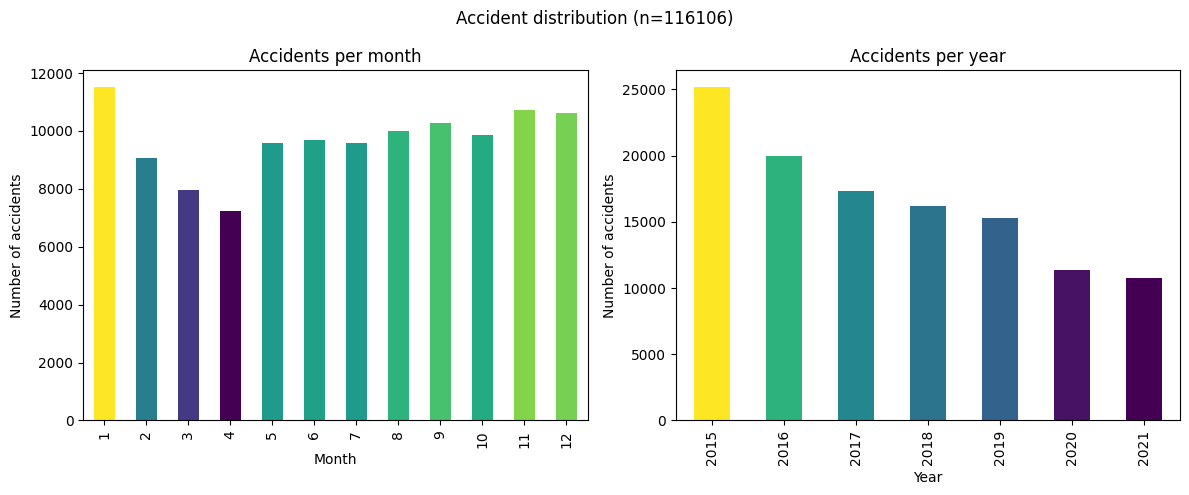

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

accidents_per_month = combined_df['Kk'].value_counts().sort_index()

colors_month = plt.cm.viridis(
    (accidents_per_month.values - accidents_per_month.values.min()) /
    (accidents_per_month.values.max() - accidents_per_month.values.min())
)

accidents_per_month.plot(
    kind='bar',
    color=colors_month,
    ax=axes[0]
)

axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of accidents")
axes[0].set_title("Accidents per month")


# --- YEAR PLOT ---
accidents_per_year = combined_df['Vuosi'].value_counts().sort_index()

colors_year = plt.cm.viridis(
    (accidents_per_year.values - accidents_per_year.values.min()) /
    (accidents_per_year.values.max() - accidents_per_year.values.min())
)

accidents_per_year.plot(
    kind='bar',
    color=colors_year,
    ax=axes[1]
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of accidents")
axes[1].set_title("Accidents per year")


plt.suptitle(f'Accident distribution (n={len(combined_df)})')
plt.tight_layout()
plt.show()

# Data Preparation

At this point the dataset includes 95 columns and 116106 rows. The data preparation starts with feature selection and feature engineering. The rows are then inspected and possible outliers and missing values are handled. The dataframes are then split into classification datasets with the severity as target variable ("Vakavuus"). The target variable is dropped for the dataframe used in clustering because we want to find patterns independent of severity. 

Further inspection of the columns revealed that the "sel"-columns are categorical variables that explain the integer values in their counterpart columns. For example, Tienpit value 1 is explained in Tienpitsel as "Liikennevirasto". The descriptive column is not always formed by simply adding "-sel" to the category column name and this makes it fairly difficult to map categories to their descriptions during analysis. That is why a mapping approach was implemented to link each integer code to its corresponding description.

Mapping directories are created in the code cell below. For easy access the integer-to-category mappings were also exported as visual tables for each column. They are stored in the directory feature_class_tables. That part of the code is commented out and should be uncommented if need for new tables.

In [57]:

# -------------------------
# Create mapping tables for integer code features
# -------------------------

# -------------------------
# SEL-based mappings (automatic)
# -------------------------
cols = combined_df.columns.tolist()
int_desc_pairs = []
for i, col in enumerate(cols):
    if col.endswith('sel') and i > 0:
        int_col = cols[i-1]
        int_desc_pairs.append((int_col, col))

mapping_dicts = {}
for int_col, sel_col in int_desc_pairs:
    mask = combined_df[[int_col, sel_col]].notna().all(axis=1)
    mapping_dict = dict(zip(combined_df.loc[mask, int_col],
                            combined_df.loc[mask, sel_col]))
    mapping_dicts[int_col] = mapping_dict
    combined_df.drop(columns=[sel_col], inplace=True)  # optional

# -------------------------
# Manual mappings for specific int/string pairs
# -------------------------
manual_pairs = [
    ("Vakavuusko", "Vakavuus"),
    ("ELY", "Elynimi"),
    ("Tienverkas", "Tienverkse"),
    ("Maankäyttö", "Maankäytse"),
    ("Lisäkaisty", "Lisäkaisse"),
    ("Solmutyyp", "Solmutyyps"),
    ("Poikkileik", "Poikleikse")
]

for int_col, str_col in manual_pairs:
    mask = combined_df[[int_col, str_col]].notna().all(axis=1)
    mapping_dict = dict(zip(combined_df.loc[mask, int_col],
                            combined_df.loc[mask, str_col]))
    mapping_dicts[int_col] = mapping_dict
    combined_df.drop(columns=[str_col], inplace=True)  # optional




# -------------------------
# Feature class tables
# -------------------------
# Most recent tables in feature_class_tables directory

# -------------------------  Uncomment if you want to create new tables  ------------------------- #
# # Make folder to store tables
# output_dir = "feature_class_tables"
# os.makedirs(output_dir, exist_ok=True)

# def save_mapping_table(mapping_dict, feature_name, output_dir):
#     # Convert np.int64 keys to plain int
#     cleaned_dict = {int(k): v for k, v in mapping_dict.items()}

#     # Create a DataFrame
#     df = pd.DataFrame(list(cleaned_dict.items()), columns=[feature_name, f"{feature_name}_desc"])
#     df = df.sort_values(by=feature_name)

#     # Plot table
#     fig, ax = plt.subplots(figsize=(6, len(df)*0.25 + 1))  # height proportional to rows
#     ax.axis('off')

#     table = ax.table(cellText=df.values,
#                      colLabels=df.columns,
#                      cellLoc='left',
#                      loc='center')

#     table.auto_set_font_size(False)
#     table.set_fontsize(10)
#     table.auto_set_column_width([0, 1])

#     plt.tight_layout()
#     filename = os.path.join(output_dir, f"{feature_name}_classes.png")
#     plt.savefig(filename, dpi=300, bbox_inches='tight')
#     plt.close()
#     print(f"Saved: {filename}")

# # Loop through all your mapping dictionaries
# for feature, mapping in mapping_dicts.items():
#     save_mapping_table(mapping, feature, output_dir)

In [58]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116106 entries, 0 to 116105
Data columns (total 63 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Onnett_id   116106 non-null  Int64 
 1   Tienpit     116106 non-null  Int64 
 2   Tie         75773 non-null   Int64 
 3   Aosa        75498 non-null   Int64 
 4   Aet         62619 non-null   Int64 
 5   Ajr         62603 non-null   Int64 
 6   Vuosi       116106 non-null  Int64 
 7   Kk          116106 non-null  Int64 
 8   Vakavuusko  116106 non-null  Int64 
 9   ELY         116106 non-null  Int64 
 10  Vkpv        116106 non-null  object
 11  Ontyyppi    116106 non-null  Int64 
 12  Onluokka    116106 non-null  Int64 
 13  Osallkm     116106 non-null  Int64 
 14  Nopraj      116106 non-null  Int64 
 15  Taajmerk    116106 non-null  Int64 
 16  Pinta       116106 non-null  Int64 
 17  Valoisuus   116106 non-null  Int64 
 18  Sää         116106 non-null  Int64 
 19  Onnpaikka   116106 non-null  Int64

The dataframe now consists mostly of numerical columns. The next step is to review columns that are not clearly explained and remove columns with a high proportion of missing values. Columns with many missing values are identified by calculating the percentage of missing entries for each column and sorting the results in descending order. Columns with the highest percentages of missing values are then removed from the dataframe.

In [59]:
# -------------------------
# Feature selection
# -------------------------

# Listing columns with most NA:s
combined_df.isna().mean().sort_values(ascending=False).head(20)


Liittyvtie    1.000000
Lähliittie    0.957995
Suuntlkm      0.948349
Nakos300      0.610658
Nakos150      0.610658
Nakos460      0.610658
Luovpvm       0.583252
Päällyslev    0.488459
Raskaskvl     0.472603
Kvl           0.471991
Tienlev       0.467934
Runkotie      0.462706
Ajr           0.460812
Aet           0.460674
Aosa          0.349749
Tie           0.347381
Lämpötila     0.004677
Y             0.000474
X             0.000465
Nopraj        0.000000
dtype: float64

In [60]:
# Listing columns with most -1, which also means missing values
missing_with_minus1 = {}
for col in combined_df.select_dtypes("integer"):
    n_missing = combined_df[col].isna().sum() + (combined_df[col] == -1).sum()
    missing_with_minus1[col] = n_missing / len(combined_df)

# Show top 20
pd.Series(missing_with_minus1).sort_values(ascending=False).head(30)

Valoohjaus    1.000000
Muuliit       1.000000
Rautatie      0.997692
Lisäkaisty    0.972387
Lähliittie    0.957995
Liitluok      0.948358
Suuntlkm      0.948349
Solmutyyp     0.948349
Mo_mol        0.944757
Liikvalot     0.908773
Maankäyttö    0.804368
Tienverkas    0.804368
Valaisomis    0.724958
Nakos300      0.610658
Nakos150      0.610658
Nakos460      0.610658
Tietyyppi     0.584759
Nopsuunvas    0.548861
Noplaji       0.545657
Nopsuunoik    0.538930
Toimenpide    0.528801
Päällyslev    0.488459
Raskaskvl     0.472603
Kvl           0.471991
Tienlev       0.467934
Talvhoitlk    0.465282
Päällystlk    0.465023
Toimluokka    0.463628
Poikkileik    0.462732
Runkotie      0.462706
dtype: float64

Based on these outputs the following columns are dropped due to high percentage of missing values and also unclear meanings: Liittyvtie,  Lähliittie, Valoohjaus, Muulit, Rautatie, Luovpvm, Nakos150, Nakos300, Nakos460, Noplaji, Nopsuunvas, Nopsuunoik, Liitluok, Lisäkaisty, Suuntlkm, Päällyslev, Raskaskvl, Kvl, Tienlev, Runkotie, Solmutyyp, Mo_mol, Maankäyttö, Tienverkas, Valaisomis, Toimenpide.

Even if some features would be interesting enough, like visibility and speedlimit types, there are others still left to complement them. Such are other features describing weather and speed. Also the id column is dropped as it is unnecessary for the analysis as well as the address. 

In [61]:
# -------------------------
# Dropping columns
# -------------------------
cols_to_drop = [
    "Onnett_id", "Katuosoite", "Liittyvtie", "Lähliittie", "Valoohjaus", "Muuliit", 
    "Rautatie", "Luovpvm", "Nakos150", "Nakos300", "Nakos460", "Noplaji", 
    "Nopsuunvas", "Nopsuunoik", "Liitluok", "Lisäkaisty", "Suuntlkm", "Päällyslev",
    "Raskaskvl", "Kvl", "Tienlev", "Runkotie", "Solmutyyp", "Mo_mol", "Maankäyttö", 
    "Tienverkas", "Valaisomis", "Toimenpide"]

combined_df = combined_df.drop(columns=cols_to_drop)
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116106 entries, 0 to 116105
Data columns (total 35 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Tienpit     116106 non-null  Int64 
 1   Tie         75773 non-null   Int64 
 2   Aosa        75498 non-null   Int64 
 3   Aet         62619 non-null   Int64 
 4   Ajr         62603 non-null   Int64 
 5   Vuosi       116106 non-null  Int64 
 6   Kk          116106 non-null  Int64 
 7   Vakavuusko  116106 non-null  Int64 
 8   ELY         116106 non-null  Int64 
 9   Vkpv        116106 non-null  object
 10  Ontyyppi    116106 non-null  Int64 
 11  Onluokka    116106 non-null  Int64 
 12  Osallkm     116106 non-null  Int64 
 13  Nopraj      116106 non-null  Int64 
 14  Taajmerk    116106 non-null  Int64 
 15  Pinta       116106 non-null  Int64 
 16  Valoisuus   116106 non-null  Int64 
 17  Sää         116106 non-null  Int64 
 18  Onnpaikka   116106 non-null  Int64 
 19  Liikvalot   116106 non-null  Int64

Based on this output there are still columns with information about the road that are somewhat unclear and also have a high percentage of missing values. These columns are "Aosa", "Aet", and "Ajr", and they are therefore dropped from the dataset. "Tie" would indicate which road number the accident happened on and would have been interesting to keep, but due to the high percentage of missing values it is also dropped.

The next step is to inspect the remaining columns with string values and decide whether they should be dropped or encoded in a way that is useful for the analysis. The columns with string values are inspected by examining their unique values and their counts.

Based on this inspection it is decided to also drop the "Raskos" column, while the other inspected columns will be encoded in the code cell below. Weekdays are encoded as 1–7, and the other columns are encoded by category (yes = 1, no = 0).

In [62]:
# -------------------------
# Inspection of clearly categorical columns
# -------------------------

string_cols = ["Vkpv", "Taajama", "Tietyö", "Raskos"]

for col in string_cols:
    print(f"\nColumn: {col}")
    print(f"Unique values: {combined_df[col].nunique()}")
    print(combined_df[col].value_counts(dropna=False).head(20))

# -------------------------
# Drop unclear road columns, Raskos column
# -------------------------
cols_to_drop = ["Raskos", "Aosa", "Aet", "Ajr", "Tie"]
combined_df = combined_df.drop(columns=cols_to_drop)

# -------------------------
# Encoding of string columns
# -------------------------

# # Map Finnish weekdays to numbers 1-7
weekday_map = {
    "Maanantai": 1,
    "Tiistai": 2,
    "Keskiviikko": 3,
    "Torstai": 4,
    "Perjantai": 5,
    "Lauantai": 6,
    "Sunnuntai": 7
}
if "Vkpv" in combined_df.columns:
    combined_df["Vkpv"] = combined_df["Vkpv"].map(weekday_map)


# Other string columns to convert to categorical codes
binary_map = {"K": 1, "E": 0}

for col in ["Taajama", "Tietyö"]:
    if col in combined_df.columns:
        combined_df[col] = combined_df[col].map(binary_map)
combined_df["Taajama"] = combined_df["Taajama"].fillna(-1).astype("int")

print(f"Unique values for weekdays: {combined_df['Vkpv'].unique()}")
print(f"Unique values for urban/rural: {combined_df['Taajama'].unique()}")
print(f"Unique values for road construction: {combined_df['Tietyö'].unique()}")

# -------------------------
# Final check of missing values after feature selection and encoding
# -------------------------
missing_with_minus1 = {}
for col in combined_df.select_dtypes("integer"):
    n_missing = combined_df[col].isna().sum() + (combined_df[col] == -1).sum()
    missing_with_minus1[col] = n_missing / len(combined_df)

# Show top 20
pd.Series(missing_with_minus1).sort_values(ascending=False).head(20)



Column: Vkpv
Unique values: 7
Vkpv
Perjantai      19431
Torstai        17200
Maanantai      16872
Tiistai        16686
Keskiviikko    16657
Lauantai       15961
Sunnuntai      13299
Name: count, dtype: int64

Column: Taajama
Unique values: 3
Taajama
E    58190
K    56393
      1523
Name: count, dtype: int64

Column: Tietyö
Unique values: 2
Tietyö
E    113247
K      2859
Name: count, dtype: int64

Column: Raskos
Unique values: 3
Raskos
ei          96859
on          13439
Ei arvoa     5808
Name: count, dtype: int64
Unique values for weekdays: [6 3 1 7 5 4 2]
Unique values for urban/rural: [ 1  0 -1]
Unique values for road construction: [0 1]


Liikvalot     0.908773
Tietyyppi     0.584759
Talvhoitlk    0.465282
Päällystlk    0.465023
Toimluokka    0.463628
Poikkileik    0.462732
Pinta         0.108341
Sää           0.095490
Lämpötila     0.045243
Nopraj        0.039119
Onnpaikka     0.023720
Taajmerk      0.013117
Taajama       0.013117
Päällyste     0.012661
Valoisuus     0.003712
Y             0.000474
X             0.000465
Tienpit       0.000052
Kk            0.000000
Vakavuusko    0.000000
dtype: float64

One final aspect to consider for categorical features is the use of the value -1. The documentation does not clearly state whether this always represents a missing value or whether it may indicate that the feature is not applicable. For example, the feature describing traffic lights ("Liikvalot") does not contain a separate category for the absence of traffic lights, so the value -1 might indicate either that there are no traffic lights or that the information is missing. Based on the code cell below, six categorical columns contain a relatively high proportion of -1 values (look above). These columns are retained in the dataset, but this ambiguity should be considered when interpreting the analysis results.

Lastly, rows with missing values are dropped from the dataset. Due to the fact that columns with high percentage of missing values have already been dropped, the amount of rows lost by dropping rows with missing values is pretty low. The dataset now consists of 30 columns and 115526 rows. 


In [63]:
combined_df = combined_df.dropna().reset_index(drop=True)
combined_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 115526 entries, 0 to 115525
Data columns (total 30 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Tienpit     115526 non-null  Int64
 1   Vuosi       115526 non-null  Int64
 2   Kk          115526 non-null  Int64
 3   Vakavuusko  115526 non-null  Int64
 4   ELY         115526 non-null  Int64
 5   Vkpv        115526 non-null  int64
 6   Ontyyppi    115526 non-null  Int64
 7   Onluokka    115526 non-null  Int64
 8   Osallkm     115526 non-null  Int64
 9   Nopraj      115526 non-null  Int64
 10  Taajmerk    115526 non-null  Int64
 11  Pinta       115526 non-null  Int64
 12  Valoisuus   115526 non-null  Int64
 13  Sää         115526 non-null  Int64
 14  Onnpaikka   115526 non-null  Int64
 15  Liikvalot   115526 non-null  Int64
 16  Maakunta    115526 non-null  Int64
 17  Kunta       115526 non-null  Int64
 18  Taajama     115526 non-null  int64
 19  Toimluokka  115526 non-null  Int64
 20  X           115

The dataframe is now ready to split for categorical problems and clustering. Categorical test set is split into train and test sets as a 30-70 split. Random state ensures that all project members get the same split. Stratify is used to ensure that the distribution of the target variable is similar in both train and test sets. The clustering dataset is not split as it is used for unsupervised learning.

In [64]:
# -------------------------
# Dataframe ready for modeling
# -------------------------

# Copy the dataframe
X = combined_df.copy()
# Target variable
y = X["Vakavuusko"]
# Drop target from features
X.drop("Vakavuusko", axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

# Dataframe for clustering
clustering_df = combined_df.drop(columns=["Vakavuusko"])
clustering_df.describe(include='all')

,Tienpit,Vuosi,Kk,ELY,Vkpv,Ontyyppi,Onluokka,Osallkm,Nopraj,Taajmerk,...,X,Y,Tietyö,Päällyste,Lämpötila,Risteys,Tietyyppi,Talvhoitlk,Poikkileik,Päällystlk
count,115526.0,115526.0,115526.0,115526.0,115526.000000,115526.0,115526.0,115526.0,115526.0,115526.0,...,115526.0,115526.0,115526.000000,115526.0,115526.0,115526.0,115526.0,115526.0,115526.0,115526.0
mean,1.514819,2017.458936,6.650832,5.002657,3.919040,57.425264,6.116363,1.706603,59.393747,0.471885,...,379986.449059,6856672.303326,0.024739,1.10679,6.891479,0.870886,-0.158328,1.104963,0.187482,6.435313
std,0.602111,1.964191,3.52819,4.282027,1.941316,35.2638,4.317622,0.759733,24.860573,0.523569,...,105734.482417,187268.562676,0.155329,0.590508,9.756803,1.558097,1.002024,2.359426,1.135214,8.462988
min,-1.0,2015.0,1.0,1.0,1.000000,0.0,1.0,0.0,-1.0,-1.0,...,51944.0,6617076.0,0.000000,-1.0,-35.0,0.0,-1.0,-1.0,-1.0,-1.0
25%,1.0,2016.0,4.0,1.0,2.000000,19.0,2.0,1.0,40.0,0.0,...,299247.5,6707436.25,0.000000,1.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0
50%,1.0,2017.0,7.0,3.0,4.000000,80.0,6.0,2.0,50.0,0.0,...,384713.0,6804785.5,0.000000,1.0,6.0,0.0,-1.0,1.0,1.0,10.0
75%,2.0,2019.0,10.0,9.0,6.000000,90.0,10.0,2.0,80.0,1.0,...,433399.25,6966591.5,0.000000,1.0,15.0,2.0,1.0,3.0,1.0,10.0
max,3.0,2021.0,12.0,14.0,7.000000,99.0,13.0,75.0,120.0,1.0,...,733231.0,7782752.0,1.000000,6.0,50.0,8.0,5.0,13.0,2.0,40.0


In [65]:
# Clustering model (initial testing)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import time

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Find optimal number of clusters
max_clusters_test = 11
wcss = []
for k in range(1, max_clusters_test):
    start_time = time.time()
    model = KMeans(init='random', n_clusters=k, random_state=123)
    model.fit(X_scaled)
    wcss.append(model.inertia_)
    end_time = time.time()
    total_time = end_time - start_time
    print(f"[Clusters {k}]: {total_time:.4f}s")

[Clusters 1]: 0.0395s
[Clusters 2]: 0.0736s
[Clusters 3]: 0.0942s
[Clusters 4]: 0.1235s
[Clusters 5]: 0.2026s
[Clusters 6]: 0.2958s
[Clusters 7]: 0.4889s
[Clusters 8]: 0.4155s
[Clusters 9]: 0.3653s
[Clusters 10]: 0.3059s


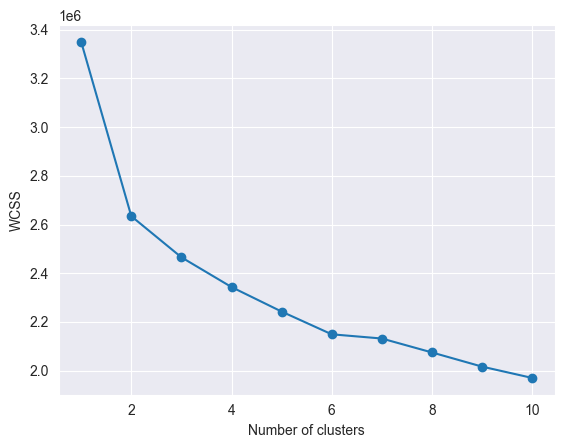

In [66]:
# Elbow method for finding optimal number of clusters
plt.plot(range(1, max_clusters_test), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Based on the graph above, the optimal clustering is k=4.

In [67]:
optimal_clusters = 4
clustering_model = KMeans(init='random', n_clusters=optimal_clusters)
clustering_model.fit(X_scaled)
clusters = clustering_model.fit_predict(X_scaled)

The plot ín the next cell attempts to visualize the clusters found by the KMeans algorithm.

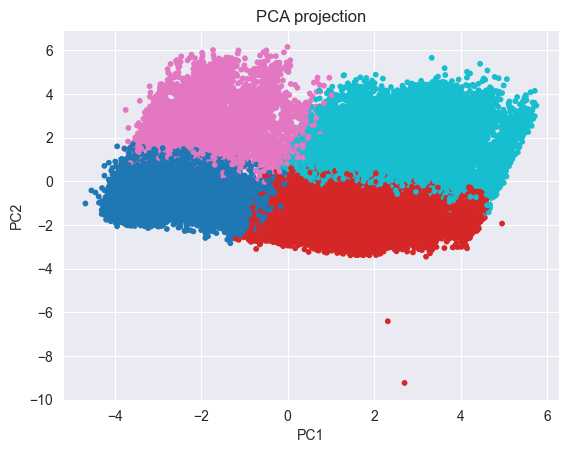

In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=10, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection")
plt.show()

The plot shows a slight division in cluster groups, though with significant blending. The number of outliers is negligible.
Next, cluster profiles will be formed to describe each accident group, which will show if there are clear factors involved.

In [69]:
clustering_df["cluster"] = clusters
cluster_profiles = clustering_df.groupby("cluster").mean()
clustering_df["cluster"].value_counts()

cluster
0    37468
1    34183
3    27988
2    15887
Name: count, dtype: int64

The current clustering got a silhouette score of ~0.123, which is very low. Anything below <0.25 typically means that there isn't a meaningful separation between clusters.
This could mean that accidents are simply not very different from each other, or that the clustering algorithm is not optimal for this task.
Another possibility is that silhouette score is not suitable for a dataset with this many features.

The cell below will use umap-learn to create a more accurate representation of the clusters.
Uniform Manifold Approximation and Projection for Dimension Reduction (UMAP) is a dimension reduction technique.
The use case for this dataset is to help visualize the many different features present in each item.

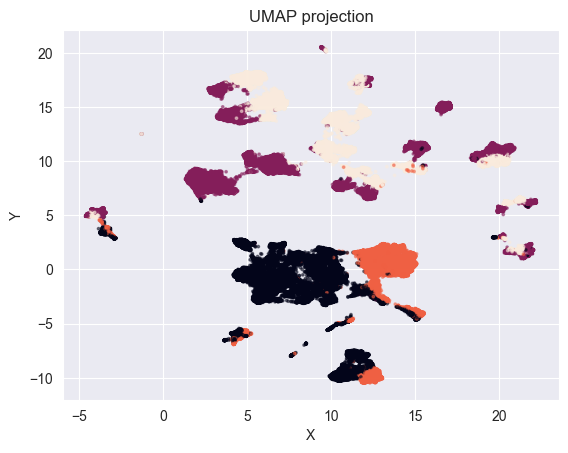

In [70]:
import umap

reducer = umap.UMAP()
X_umap = reducer.fit_transform(X_scaled)

# Display UMAP plot to visualize dimensions more easily.
plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters, s=3, alpha=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("UMAP projection")
plt.show()

Clusters seem more defined below Y < 5, while above they seem to blend together. This plot does still show that at least some clusters are properly separated.

In [71]:
# Add clusters to the original data and compare with severity
comparison_cluster_df = combined_df.copy()
comparison_cluster_df["cluster"] = clusters
pd.crosstab(comparison_cluster_df["cluster"], comparison_cluster_df["Vakavuusko"], normalize="index")

Vakavuusko,0,1,2
cluster,,,
0,0.750294,0.006325,0.243381
1,0.742065,0.016002,0.241933
2,0.728961,0.009568,0.261472
3,0.762220,0.019687,0.218093


Comparing the severity of each accident with the cluster it belongs to shows that they have extremely similar rates.  
This suggests that there is very little difference between each cluster, and that this algorith may not be suitable for this particular dataset.  
Based on these findings, it is safe to say that the clusters are not meaningfully separated by accident severity.  
  
The divisions in the clusters might still indicate that there is a better number of clusters than k=4.  
Next, a new model will be built with the smallest number of clusters possible: k=2.

In [72]:
clustering_model = KMeans(init='random', n_clusters=2, random_state=123)
clustering_model.fit(X_scaled)
clusters_2 = clustering_model.fit_predict(X_scaled)
comparison_cluster_df = combined_df.copy()
comparison_cluster_df["cluster"] = clusters_2
pd.crosstab(comparison_cluster_df["cluster"], comparison_cluster_df["Vakavuusko"], normalize="index")

Vakavuusko,0,1,2
cluster,,,
0,0.744119,0.007262,0.248620
1,0.750994,0.017699,0.231307


Decreasing the number of clusters from 4 --> 2 has marginally improved the silhouette score, showing that the new clusters are slightly more defined.  
The result still indicates that even with an optimal number of clusters, this algorithm struggles to find any real groups in the dataset.

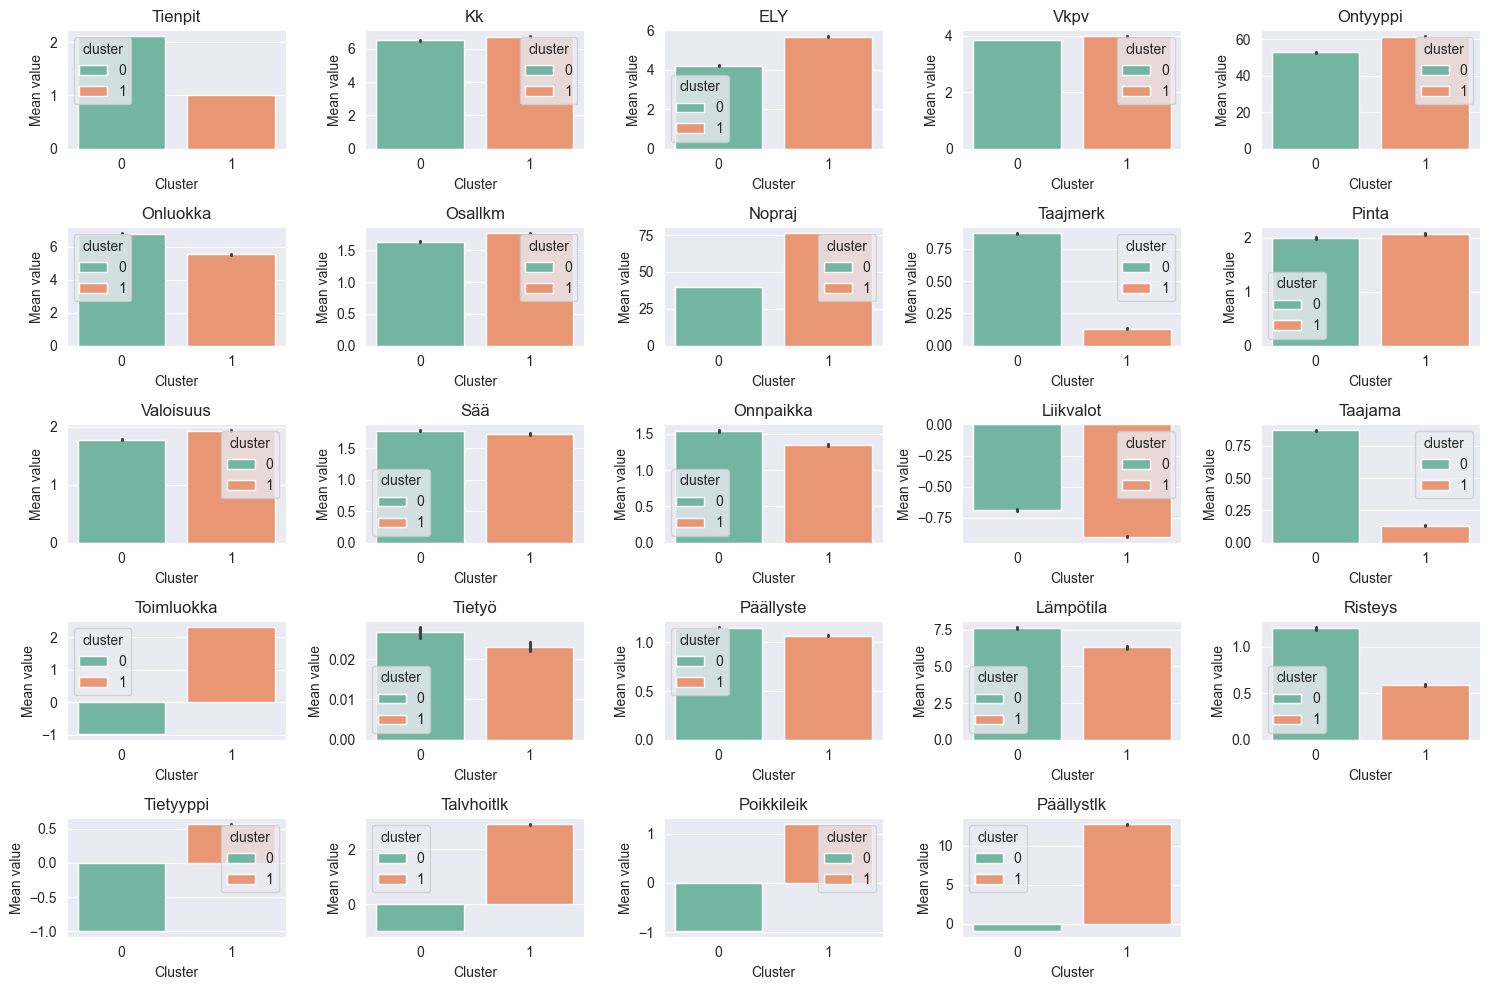

In [73]:
# Create seaborn graph to show differences in the clusters
import seaborn as sns

feature_list = comparison_cluster_df.copy().drop(columns=["cluster", "Vuosi", "Vakavuusko", "Kunta", "Maakunta", "X", "Y"]).columns
n_features = len(feature_list)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*2))
axes = axes.flatten()

for i, feature in enumerate(feature_list):
    sns.barplot(
        data=comparison_cluster_df,
        x="cluster",
        y=feature,
        ax=axes[i],
        hue="cluster",
        palette="Set2"
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Mean value")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")
    
plt.tight_layout()
plt.show()

Since it has been established that Cluster 0 accounts for 0.7% of deaths vs Cluster 1 with 1.7%, the graphs above seem to indicate  
that conurbation areas suffer more fatalities, especially if there isn't a sign indicating it.  
It's difficult to find any proper accident profiles from these values, as the clusters still aren't very well-defined.

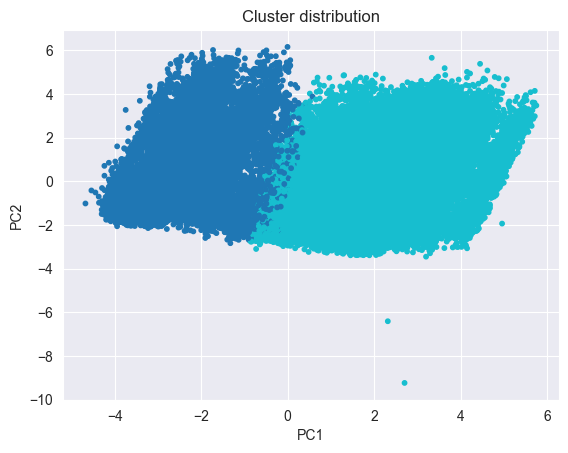

In [74]:
# Cluster distribution when number of clusters = 2
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_2, s=10, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster distribution")
plt.show()

It seems that the split between the clusters runs messily through the middle, with significant bleeding.  
For a final visualization, the chart will again be generated as a UMAP.

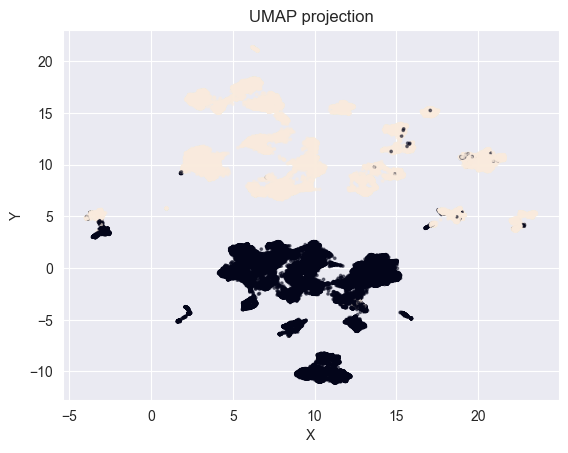

In [75]:
reducer = umap.UMAP()
X_umap = reducer.fit_transform(X_scaled)

# Display UMAP plot to visualize dimensions more easily.
plt.scatter(X_umap[:,0], X_umap[:,1], c=clusters_2, s=3, alpha=0.5)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("UMAP projection")
plt.show()

This visualization strongly indicates that the data is best represented by 2 clusters, as there is now a defined split.  
Slight bleeding is observed in some places, but for the most part, the cluster items stay in their own groups.  
Despite this, it seems that there still aren't many differences between the groups.

## Evaluation
The two clustering algorithms (k=4 and k=2) will be evaluated with silhouette score.  
Silhouette score indicates how different values within a given cluster are from other clusters.
It is scored from 1 to -1, with 1 meaning extreme differences and -1 meaning essentially no differences.  
Typically, the score is understood as:
\>0.7 is strong
0.5-0.7 is reasonable
<0.25 is weak

In [76]:
# Determine how diverse the clusters are using silhouette score.
# Run on 10000 random samples, because 100k+ samples is extremely expensive.
from sklearn.metrics import silhouette_score
import numpy as np

sample_size = 10000
idx = np.random.choice(len(X_scaled), sample_size, replace=False)
score = silhouette_score(X_scaled[idx], clusters[idx])
print(f"Silhouette score [4 clusters]: {score}")

Silhouette score [4 clusters]: 0.1214531264359962


In [77]:
# Perform silhouette score test with just 2 clusters
sample_size = 10000
idx = np.random.choice(len(X_scaled), sample_size, replace=False)
score = silhouette_score(X_scaled[idx], clusters_2[idx])
print(f"Silhouette score [2 clusters]: {score}")

Silhouette score [2 clusters]: 0.21035781191229716


Silhouette score based on number of clusters:  
4 = 0.121
2 = 0.21  
Both scores fall in the weak category (<0.25) which indicates that accident profiles are weak.  
Visualization of the clusters also showed that there weren't many meaningful differences in features between each cluster.  
Accident severity slightly correlates with the clusters, but as the other features are weak, it is difficult to reach any conclusions.  
The silhouette score may be misleading however, as the dataset has an extremely high number of columns (30).  
This causes an issue with the evaluation called "curse of dimensionality" as distances between items become more similar.
  
The elbow method indicated that 4 clusters would be optimal, but testing the algorithm and analyzing the data proved that 2 is better.  
It's possible that the data does not have clearly defined accident profiles, or that the KMeans clustering algorith is not suitable for finding them.

              precision    recall  f1-score   support

   No injury       0.83      0.96      0.89     25957
      Injury       0.73      0.39      0.51      8238
       Death       0.63      0.07      0.12       463

    accuracy                           0.81     34658
   macro avg       0.73      0.47      0.51     34658
weighted avg       0.80      0.81      0.79     34658


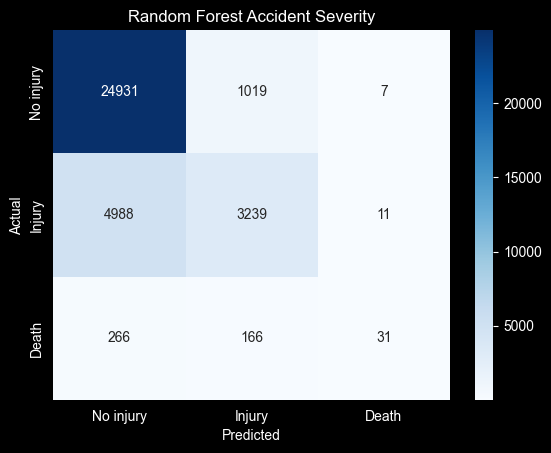

In [76]:
rf_predict_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=5040)
X = combined_df.drop(columns=["Vakavuusko"])
y = combined_df["Vakavuusko"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5040)
rf_predict_model.fit(X_train, y_train)
y_pred = rf_predict_model.predict(X_test)

labels = ["No injury", "Injury", "Death"]
print(classification_report(y_test, y_pred, labels=[0, 2, 1], target_names=labels))
cm = confusion_matrix(y_test, y_pred, labels=[0,2,1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Accident Severity")
plt.show()

The Random Forest model performs well when predicting accidents with no injuries, achieving a good F1-score. This shows that the majority of non-injury accidents are correctly identified.

Performance is noticeably weaker for accidents involving injuries. While the precision for this class is relatively high, the recall is lacking, meaning that a large proportion of injury accidents are incorrectly classified as less severe.

The model performs particularly poorly for fatal accidents. Although the precision is moderate, the recall is quite dreadful, indicating that the model detects only a small fraction of fatal accidents.

Overall, the results suggest that the model is effective at identifying non-severe accidents but struggles to detect more severe outcomes. This is likely influenced by the strong class imbalance in the dataset, where fatal accidents represent only a very small portion of the observations.

The importance of different features is important to understand which is why its good to show a chart of different features and their importance.

Ontyyppi     0.118836
Onluokka     0.116797
X            0.080836
Y            0.078383
Lämpötila    0.065471
Kunta        0.060184
Kk           0.045809
Nopraj       0.042222
Vkpv         0.040976
Vuosi        0.040744
dtype: float64


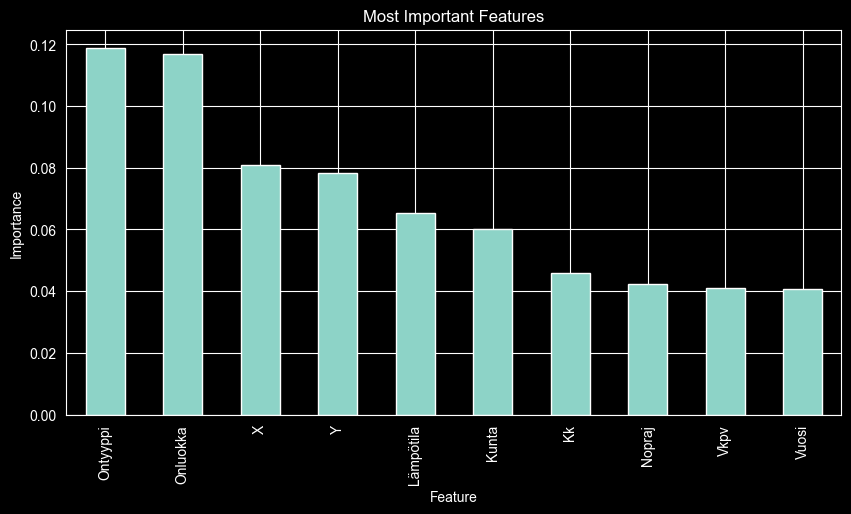

In [82]:
importance = pd.Series(rf_predict_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(10))
importance.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Most Important Features")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()

Naturally the accident type has a very strong correlation with the severity of an accident. A crash on the highway is more dangerous than an accident while reversing. Similarly the type of collision is important. Interestingly the coordinates also play a key role in predicting the severity of the accident, but of course once again, the highways are more dangerous. Temperature naturally influences severity among other things.

The Random Forest model offers a solid starting point for predicting accident severity, but exploring other models is essential to fully evaluate predictive performance. Logistic Regression will be examined next.

              precision    recall  f1-score   support

   No injury       0.85      0.46      0.60     17279
      Injury       0.34      0.45      0.38      5530
       Death       0.03      0.58      0.05       297

    accuracy                           0.46     23106
   macro avg       0.40      0.50      0.35     23106
weighted avg       0.72      0.46      0.54     23106


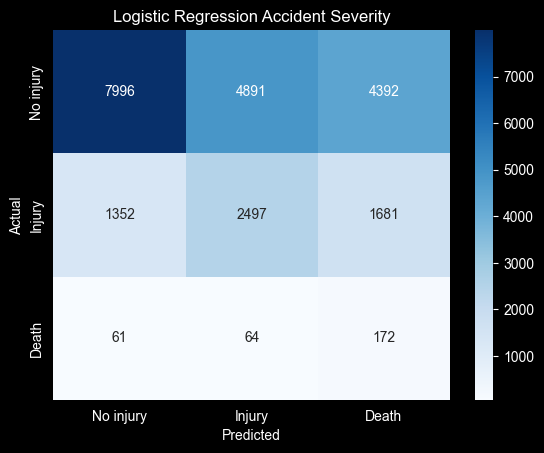

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5040, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
logreg_severity_model = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=5040)
logreg_severity_model.fit(X_train_scaled, y_train)
y_pred = logreg_severity_model.predict(X_test_scaled)

labels = ["No injury", "Injury", "Death"]
print(classification_report(y_test, y_pred, labels=[0, 2, 1], target_names=labels))
cm = confusion_matrix(y_test, y_pred, labels=[0,2,1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Accident Severity")
plt.show()

Overall Logistic Regression shows far worse results. While there are improvements with the recall of more severe accidents, Everything else is significantly worse.

Next an attempt at predicting results using KNN will be tried.

              precision    recall  f1-score   support

   No injury       0.81      0.91      0.86     17279
      Injury       0.54      0.36      0.43      5530
       Death       0.38      0.02      0.03       297

    accuracy                           0.77     23106
   macro avg       0.58      0.43      0.44     23106
weighted avg       0.74      0.77      0.74     23106


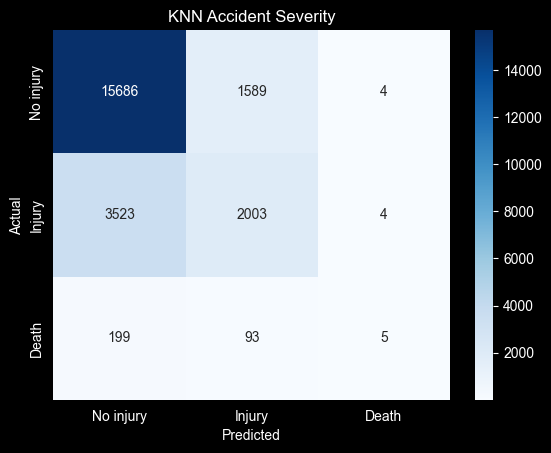

In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_model = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

labels = ["No injury", "Injury", "Death"]
print(classification_report(y_test, y_pred, labels=[0, 2, 1], target_names=labels))
cm = confusion_matrix(y_test, y_pred, labels=[0,2,1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Accident Severity")
plt.show()

Overall this is an improvement over Logistic Regression, but Random Forest remains king when it comes to predicting the severity of accidents.

While the severity of an accident can be predicted using available data, it is surprisingly difficult. Most accidents are not that severe even when the conditions are pretty bad.

## Preprocessing for weather conditions analysis

In order to use the dataframe for determeining the effect of weather conditions on accident severity, only the features related to weather conditions are selected. These features are "Pinta", "Valoisuus", "Sää", and "Lämpötila". The categorical features are one-hot encoded and the numerical feature is left as is. Even though random forests can handle categorical features without encoding in theory, in this dataset the categories were ordinal as opposed to nominal thus making one-hot encoding a more suitable choice. The transformed data is then ready for modeling.

In [111]:
# Dataframe for weathers effects of accident severity analysis
X_train_weather = X_train[["Pinta", "Valoisuus", "Sää", "Lämpötila"]]
X_test_weather = X_test[["Pinta", "Valoisuus", "Sää", "Lämpötila"]]

cat_cols = ["Pinta", "Sää", "Valoisuus"]
num_cols = ["Lämpötila"]

# Preprocessing: One-hot encode categorical columns
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

preprocess.fit(X_train_weather)

X_train_transformed = preprocess.transform(X_train_weather)
X_test_transformed = preprocess.transform(X_test_weather)

X_train_transformed.toarray()[:5]  # Show first 5 rows of transformed data

array([[ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0.,  7.],
       [ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0., 19.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0., 10.],
       [ 0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0., 23.]])

# Modeling

In this section models are trained to answer the three research questions posed at the beginning of the notebook.

For the second research question, the effect of weather conditions on accident severity is analyzed using a random forest classifier. Due to the imbalanced nature of the target variable, SMOTE is used to oversample the minority classes in the training data.

## Random Forest for determining the effect of weather conditions on accident severity

The purpose of this research question is to determine the effect of weather conditions on accident severity. The features related to weather conditions are "Pinta", "Valoisuus", "Sää", and "Lämpötila". A random forest classifier is used for this analysis. Due to the imbalanced nature of the target variable, SMOTE is used to oversample the minority classes in the training data. Different SMOTE parameters are tested to find the best combination for this dataset. After finding the best SMOTE parameters, a hyperparameter tuning is performed for the random forest model using a grid search approach.

### SMOTE parameter tuning

In order to find the best SMOTE parameters for this dataset, different combinations of sampling strategies and k_neighbors are tested. The sampling strategies are defined as dictionaries that specify the desired number of samples for each class after oversampling. The k_neighbors parameter specifies the number of nearest neighbors to use for generating synthetic samples. The model is trained on the oversampled training data and evaluated on the test data for each combination of parameters. The best combination is selected based on the highest accuracy score on the test set.

In [160]:
strategies = [
    {1: 30000, 2: 30000},
    {1: 40000, 2: 20000},
    {1: 50000, 2: 50000},
]

neighbors = [4, 5, 6]
best_f1 = 0
best_params = None

for s in strategies:
    for k in neighbors:
        sm = SMOTE(sampling_strategy=s, k_neighbors=k, random_state=42)
        X_res, y_res = sm.fit_resample(X_train_transformed, y_train)

        model = RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_res, y_res)

        y_pred = model.predict(X_test_transformed)
        current_f1 = f1_score(y_test, y_pred, average='macro')

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_params = (s, k)

print("Best SMOTE params:", best_params)
print("Best f1-score:", best_score)


Best SMOTE params: ({1: 40000, 2: 20000}, 6)
Best accuracy: 0.500605920710947


The best SMOTE parameters found for this dataset are a sampling strategy of {1: 40000, 2: 20000} and k_neighbors of 6. This means that after oversampling, the minority class with label 1 will have 40,000 samples and the minority class with label 2 will have 20,000 samples in the training data. This combination of parameters is therefore used for the subsequent hyperparameter tuning of the random forest model.

In [161]:
sm = SMOTE(sampling_strategy={1: 40000, 2: 20000}, k_neighbors=6, random_state=42)
X_res, y_res = sm.fit_resample(X_train_transformed, y_train)

In [162]:
print("Class distribution after SMOTE:")
print(pd.Series(y_res).value_counts())

print("\nPercentages:")
print(pd.Series(y_res).value_counts(normalize=True))

Class distribution after SMOTE:
Vakavuusko
0    60474
1    40000
2    20000
Name: count, dtype: Int64

Percentages:
Vakavuusko
0    0.501967
1    0.332022
2    0.166011
Name: proportion, dtype: Float64


### Random Forest hyperparameter tuning

After finding the best SMOTE parameters, a hyperparameter tuning is performed for the random forest model using a grid search approach. The hyperparameters tested include the number of trees (n_estimators), maximum depth of the trees (max_depth), minimum samples required to be at a leaf node (min_samples_leaf), minimum samples required to split an internal node (min_samples_split), maximum number of samples to draw from X to train each base estimator (max_samples), maximum number of features to consider when looking for the best split (max_features), and the function to measure the quality of a split (criterion). The model is trained on the oversampled training data and evaluated on the test data for each combination of hyperparameters. The best combination is selected based on the highest accuracy score on the test set.

In [169]:
warnings.filterwarnings("ignore", message="`sklearn.utils.parallel.delayed`")
# Hyperparameter grid
n_trees = [100, 200]
max_depths = [None, 20, 30]
min_samples_leaf = [1, 3, 5, 10]
min_samples_split = [2, 5, 10]
max_samples = [0.6, 0.8]
max_features = [0.6, 0.8]
criteria = ["gini", "entropy"]

best_params = None
best_f1 = 0
start_time = datetime.datetime.now()

for n in n_trees:
    for depth in max_depths:
        for leaf in min_samples_leaf:
            for split in min_samples_split:
                for ms in max_samples:
                    for mf in max_features:
                        for crit in criteria:

                            model = RandomForestClassifier(
                                n_estimators=n,
                                max_depth=depth,
                                min_samples_leaf=leaf,
                                min_samples_split=split,
                                max_samples=ms,
                                max_features=mf,
                                criterion=crit,
                                class_weight='balanced_subsample',
                                random_state=42,
                                n_jobs=-1
                            )

                            model.fit(X_res, y_res)

                            y_pred = model.predict(X_test_transformed)
                            current_f1 = f1_score(y_test, y_pred, average='macro')

                            if current_f1 > best_f1:
                                best_f1 = current_f1
                                best_params = (n, depth, leaf, split, ms, mf, crit)

end_time = datetime.datetime.now()
elapsed = end_time - start_time

print(f"Tuning took: {str(elapsed).split('.')[0]}")
print("Best parameters:")
print(f"  n_estimators={best_params[0]}")
print(f"  max_depth={best_params[1]}")
print(f"  min_samples_leaf={best_params[2]}")
print(f"  min_samples_split={best_params[3]}")
print(f"  max_samples={best_params[4]}")
print(f"  max_features={best_params[5]}")
print(f"  criterion={best_params[6]}")
print(f"Best f1-score: {best_f1:.4f}")


Tuning took: 1:51:27
Best parameters:
  n_estimators=100
  max_depth=20
  min_samples_leaf=10
  min_samples_split=2
  max_samples=0.6
  max_features=0.6
  criterion=gini
Best accuracy: 0.5006


The best hyperparameters found for the random forest model are n_estimators=100, max_depth=20, min_samples_leaf=10, min_samples_split=2, max_samples=0.6, max_features=0.6, and criterion="gini". It achieves a f1-score of 0.5006 on the test set.

### Training the final model

The hyperparameters found in the previous step are used to train the final random forest model on the oversampled training data. The model is then evaluated on the test data to determine its accuracy. For comparison, another random forest model with the same hyperparameters is trained on the original training data without SMOTE oversampling and evaluated on the test data as well.

In [173]:
final_forest_model = RandomForestClassifier(
                                n_estimators=100,
                                max_depth=20,
                                min_samples_leaf=10,
                                min_samples_split=2,
                                max_samples=0.6,
                                max_features=0.6,
                                criterion="gini",
                                class_weight='balanced_subsample',
                                random_state=42,
                                n_jobs=-1
                            )

final_forest_model_noTransformed = RandomForestClassifier(
                                n_estimators=100,
                                max_depth=20,
                                min_samples_leaf=10,
                                min_samples_split=2,
                                max_samples=0.6,
                                max_features=0.6,
                                criterion="gini",
                                random_state=42,
                                n_jobs=-1
                            )

final_forest_model_SMOTE = clone(final_forest_model)
final_forest_model_noSMOTE = clone(final_forest_model)

final_forest_model_SMOTE.fit(X_res, y_res)
final_forest_model_noSMOTE.fit(X_train_transformed, y_train)
final_forest_model_noTransformed.fit(X_train_weather, y_train)

accuracy = final_forest_model_SMOTE.score(X_test_transformed, y_test)
accuracy_noSMOTE = final_forest_model_noSMOTE.score(X_test_transformed, y_test)
accuracy_noTransformed = final_forest_model_noTransformed.score(X_test_weather, y_test)

f1_score_SMOTE = f1_score(y_test, final_forest_model_SMOTE.predict(X_test_transformed), average='macro')
f1_score_noSMOTE = f1_score(y_test, final_forest_model_noSMOTE.predict(X_test_transformed), average='macro')
f1_score_noTransformed = f1_score(y_test, final_forest_model_noTransformed.predict(X_test_weather), average='macro')

print(f"Final model accuracy with SMOTE: {accuracy:.4f}")
print(f"Final model accuracy without SMOTE: {accuracy_noSMOTE:.4f}")
print(f"Final model accuracy without transformation: {accuracy_noTransformed:.4f}")
print("")
print(f"Final model F1 score with SMOTE: {f1_score_SMOTE:.4f}")
print(f"Final model F1 score without SMOTE: {f1_score_noSMOTE:.4f}")
print(f"Final model F1 score without transformation: {f1_score_noTransformed:.4f}")

Final model accuracy with SMOTE: 0.5040
Final model accuracy without SMOTE: 0.4652
Final model accuracy without transformation: 0.7477

Final model F1 score with SMOTE: 0.3447
Final model F1 score without SMOTE: 0.3306
Final model F1 score without transformation: 0.2852


# Evaluation

In this section the results from the three models are evaluated.

## Weather conditions and accident severity

The final random forest model trained with SMOTE oversampling is evaluated using a correlation matrix, feature importance analysis, confusion matrix, and classification report.

### Correlation matrix

Correlation matrix is calculated for the features related to weather conditions to understand the relationships between them. It is then visualized using a heatmap to easily identify any strong correlations between the features.

To calculate the correlation matrix, some sanitation of the data is performed. The value 4 in the "Valoisuus" column is replaced with 0 and the values 2 and 1 are swapped in the "Vakavuusko" column to make the values more linearly logical. Any rows with missing values in the selected features are dropped from the dataframe.

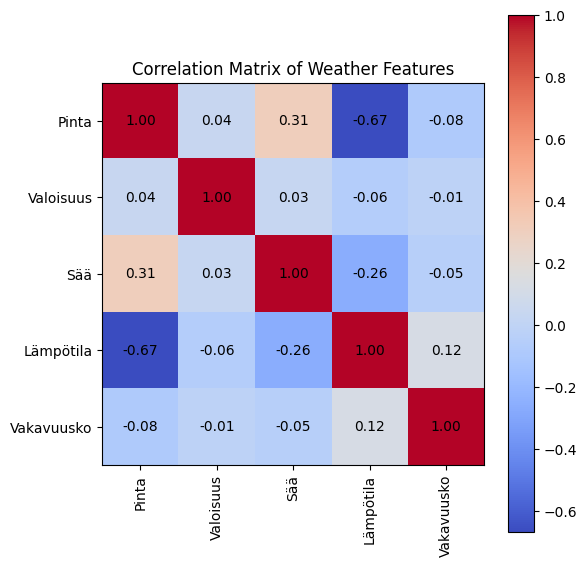

In [174]:
weather_df = combined_df[["Pinta", "Valoisuus", "Sää", "Lämpötila", "Vakavuusko"]]

weather_df["Valoisuus"] = weather_df["Valoisuus"].replace(4, 0)
weather_df["Vakavuusko"] = (
    weather_df["Vakavuusko"]
    .replace({1: 2, 2: 1})
)

weather_df = weather_df[
    ~weather_df[["Pinta", "Valoisuus", "Sää", "Lämpötila", "Vakavuusko"]].isin([-1]).any(axis=1)
]

weather_encoded = pd.get_dummies(weather_df, drop_first=False)
corr_matrix = weather_df.corr()

plt.figure(figsize=(6, 6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color='black')

plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title("Correlation Matrix of Weather Features")
plt.tight_layout()
plt.show()

The correlation matrix shows that there are some correlations between the features related to weather conditions. The strongest correlation is between "Pinta" and "Lämpötila" with a correlation coefficient of -0.67 indicating that colder temperatures are associated with more slippery road conditions. There is also a moderate correlation between "Sää" and "Lämpötila" with a coefficient of -0.26, suggesting that certain weather conditions are more likely to occur at specific temperature ranges.

From the point of view of the research question, the most important row is the bottom row showing only small correlations between the weather features and the target variable "Vakavuusko". The strongest correlation with the target variable is with "Lämpötila" with a coefficient of 0.12, indicating that lower temperatures are associated with more severe accidents. This makes is logically sound as colder temperatures can lead to more hazardous driving conditions such as icy roads.

### Feature importance analysis

Feature importance analysis is performed to determine which features related to weather conditions are the most important for predicting accident severity. The feature importances are extracted from the final random forest model and grouped by the original feature names. The grouped feature importances are then visualized using a horizontal bar chart.

In [175]:
ohe = preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = list(cat_feature_names) + num_cols

importances = final_forest_model_SMOTE.feature_importances_

grouped = {}

for name, imp in zip(feature_names, importances):
    base = name.split("_")[0]  # extract original feature name
    grouped[base] = grouped.get(base, 0) + imp

grouped_importances = pd.Series(grouped).sort_values(ascending=False)

print("Feature importances grouped by original feature (SMOTE):")
print(grouped_importances)


Feature importances grouped by original feature (SMOTE):
Lämpötila    0.316079
Valoisuus    0.265275
Pinta        0.216464
Sää          0.202182
dtype: float64


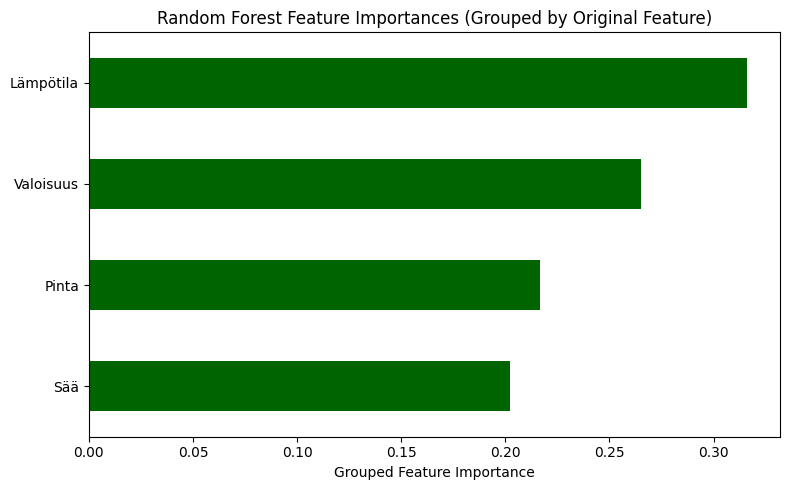

In [176]:
plt.figure(figsize=(8, 5))
grouped_importances.plot(kind="barh", color="darkgreen")
plt.xlabel("Grouped Feature Importance")
plt.title("Random Forest Feature Importances (Grouped by Original Feature)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


As can be seen from the feature importance analysis, the single most important feature for predicting accident severity is the temperature ("Lämpötila") with an importance score of 0.32, with other features around 0.20 to 0.26. This is somewhat surprising as one might expect that the other features such as the condition of the road surface ("Pinta") and lighting conditions ("Valoisuus") would have the most significant impact on accident severity since they directly affect the driving conditions. However, as the correlation matrix also showed, there is a correlation between temperature and road surface conditions as well as between temperature and weather conditions, which might explain why temperature is the most important feature in the model. It works as a sort of proxy for the other weather-related features.

### Confusion matrix and classification report

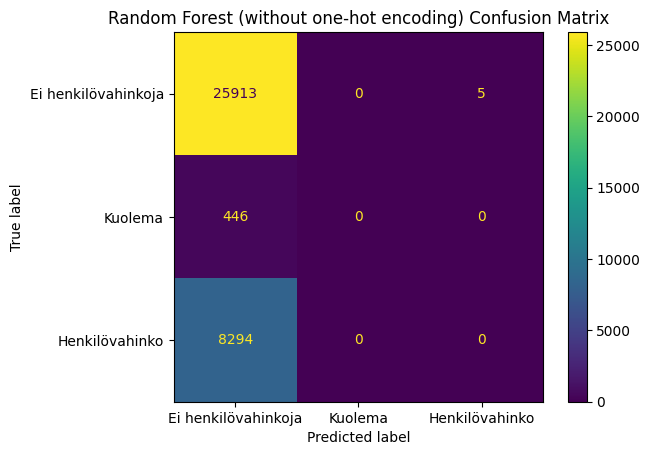

                     precision    recall  f1-score   support

Ei henkilövahinkoja       0.75      1.00      0.86     25918
            Kuolema       0.00      0.00      0.00       446
     Henkilövahinko       0.00      0.00      0.00      8294

           accuracy                           0.75     34658
          macro avg       0.25      0.33      0.29     34658
       weighted avg       0.56      0.75      0.64     34658

Accuracy: 0.7477


In [177]:
y_pred = final_forest_model_noTransformed.predict(X_test_weather)
cm = confusion_matrix(y_test, y_pred)

cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ei henkilövahinkoja', 'Kuolema', 'Henkilövahinko'])
cmd.plot()
plt.title('Random Forest (without one-hot encoding) Confusion Matrix')
plt.show()

forest_report = classification_report(y_test, y_pred, target_names=['Ei henkilövahinkoja', 'Kuolema', 'Henkilövahinko'], zero_division=0)
print(forest_report)
print(f"Accuracy: {final_forest_model_noTransformed.score(X_test_weather, y_test):.4f}")

Above is the confusion matrix and classification report for the random forest model trained without one-hot encoding. The accuracy of this model is 0.75, which on paper seems pretty good. However, the classification report reveals that the model performs very poorly on the minority classes, with an F1 score of 0.00 for both "Kuolema" and "Henkilövahinko". This shows that the model is not able to effectively predict the more severe accident outcomes, and is predominantly predicting the majority class "Ei henkilövahinkoja" giving it a high accuracy since the majority of the test samples belong to that class.

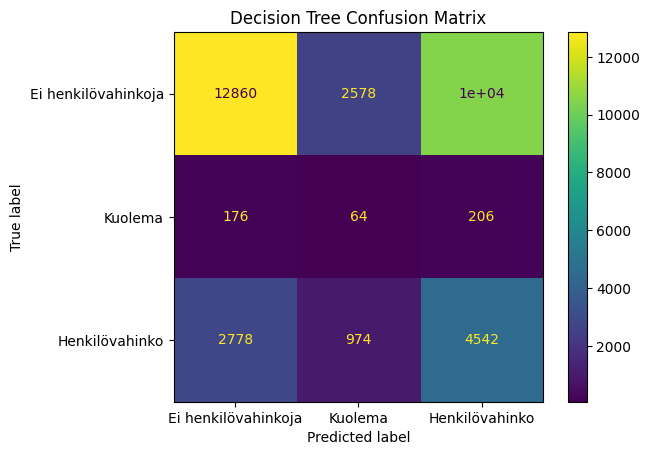

                     precision    recall  f1-score   support

Ei henkilövahinkoja       0.81      0.50      0.62     25918
            Kuolema       0.02      0.14      0.03       446
     Henkilövahinko       0.30      0.55      0.39      8294

           accuracy                           0.50     34658
          macro avg       0.38      0.40      0.34     34658
       weighted avg       0.68      0.50      0.55     34658

Accuracy: 0.5040


In [178]:
y_pred = final_forest_model_SMOTE.predict(X_test_transformed)
cm = confusion_matrix(y_test, y_pred)

cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ei henkilövahinkoja', 'Kuolema', 'Henkilövahinko'])
cmd.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()

forest_report = classification_report(y_test, y_pred, target_names=['Ei henkilövahinkoja', 'Kuolema', 'Henkilövahinko'])
print(forest_report)
print(f"Accuracy: {final_forest_model_SMOTE.score(X_test_transformed, y_test):.4f}")

This confusion matrix and classification report are for the random forest model trained with SMOTE oversampling. The accuracy of this model is 0.5040, which is a lot lower than the model in the previous confusion matrix, but since random guess has a chance of success of 33% it still has some predictive value.

As can be seen from the classification report, the model performs much better on the minority classes with F1 scores of 0.03 for "Kuolema" and 0.55 for "Henkilövahinko". This shows that the SMOTE oversampling has helped the model to better learn the patterns in at least one of the minority classes and thus improve its ability to predict more severe accident outcomes, even though it has come at the cost of overall accuracy due to a decrease in performance on the most common class "Ei henkilövahinkoja" (F1 score of 0.62 compared to 0.86 in the previous model).

The perfomance of this model is still not ideal, and there is room for improvement. Especially the performance on the "Kuolema" class is very poor, which might be due to the fact that it is the most underrepresented class in the dataset. It is possible that further tuning of the SMOTE parameters or trying different oversampling techniques could help to improve the performance on this class. The inbalanced nature of the dataset and the fact that the weather features alone may not be sufficient to predict accident severity are likely contributing factors to the model's performance.

### Conclusion on weather conditions and accident severity

